# дз-2

функция: $f(x) = |\mathrm{tg}(x)|^{x}\sin(x) + \tfrac{1}{2}$, промежуток $x \in [-2;\,1]$.

1. построить интерполяционный полином в форме ньютона степени $m=2$ руками, узлы выбрать по чебышёву;
2. добавить произвольный узел, не совпадающий с уже выбранными, расширить полином до степени 3;
3. построить графики ошибок обоих полиномов на всём промежутке, сравнить.

## 1. выбор узлов по чебышёву

для степени $m$ узлы интерполирования на $[a,b]$ задаются формулой
$$
x_i = \frac{a+b}{2} + \frac{b-a}{2}\,\xi_i,\qquad \xi_i = -\cos\!\frac{2i+1}{2m+2}\pi,\qquad i=0,\dots,m.
$$
при $m=2$ имеем три узла. вычислим $\xi_i$:

$\xi_0 = -\cos\frac{\pi}{6} = -\frac{\sqrt{3}}{2} \approx -0{,}8660$,

$\xi_1 = -\cos\frac{3\pi}{6} = 0$,

$\xi_2 = -\cos\frac{5\pi}{6} = \frac{\sqrt{3}}{2} \approx 0{,}8660$.

центр и полудлина: $\frac{a+b}{2} = -\frac{1}{2}$, $\frac{b-a}{2} = \frac{3}{2}$.

$x_0 = -\tfrac{1}{2} + \tfrac{3}{2}\cdot(-\tfrac{\sqrt3}{2}) = -\tfrac{1}{2} - \tfrac{3\sqrt3}{4} \approx -1{,}7990$,

$x_1 = -\tfrac{1}{2}$,

$x_2 = -\tfrac{1}{2} + \tfrac{3\sqrt3}{4} \approx 0{,}7990$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a, b = -2.0, 1.0
m = 2

def f(x):
    return np.abs(np.tan(x))**x * np.sin(x) + 0.5

xi = np.array([-np.cos((2*i + 1) * np.pi / (2*m + 2)) for i in range(m + 1)])
x_nodes = (a + b)/2 + (b - a)/2 * xi

for i, xn in enumerate(x_nodes):
    print(f"x{i} = {xn:.6f}")

x0 = -1.799038
x1 = -0.500000
x2 = 0.799038


## 2. значения функции в узлах

$f(x_0) = |\mathrm{tg}(x_0)|^{x_0}\sin(x_0) + \tfrac{1}{2}$ итд

In [2]:
y_nodes = f(x_nodes)
for i, (xn, yn) in enumerate(zip(x_nodes, y_nodes)):
    print(f"f(x{i}) = f({xn:.6f}) = {yn:.6f}")

f(x0) = f(-1.799038) = 0.429522
f(x1) = f(-0.500000) = -0.148641
f(x2) = f(0.799038) = 1.232481


получаем:

$f(x_0) \approx 0{,}429522$,

$f(x_1) \approx -0{,}148641$,

$f(x_2) \approx 1{,}232481$.

## 3. разделённые разности

по определению,
$$
f(x_i;x_{i+1}) = \frac{f(x_{i+1}) - f(x_i)}{x_{i+1} - x_i},\qquad
f(x_i;x_{i+1};x_{i+2}) = \frac{f(x_{i+1};x_{i+2}) - f(x_i;x_{i+1})}{x_{i+2} - x_i}.
$$

вычисления:

$f(x_0;x_1) = \dfrac{-0{,}148641 - 0{,}429522}{-0{,}5 - (-1{,}799038)} = \dfrac{-0{,}578164}{1{,}299038} \approx -0{,}445071$,

$f(x_1;x_2) = \dfrac{1{,}232481 - (-0{,}148641)}{0{,}799038 - (-0{,}5)} = \dfrac{1{,}381122}{1{,}299038} \approx 1{,}063189$,

$f(x_0;x_1;x_2) = \dfrac{1{,}063189 - (-0{,}445071)}{0{,}799038 - (-1{,}799038)} = \dfrac{1{,}508259}{2{,}598076} \approx 0{,}580529$.

таблица разделённых разностей:

| $x_i$ | $f(x_i)$ | $f(\cdot;\cdot)$ | $f(\cdot;\cdot;\cdot)$ |
|---|---|---|---|
| $x_0=-1{,}799038$ | $\phantom{-}0{,}429522$ | $-0{,}445071$ | $\phantom{-}0{,}580529$ |
| $x_1=-0{,}5$ | $-0{,}148641$ | $\phantom{-}1{,}063189$ | |
| $x_2=\phantom{-}0{,}799038$ | $\phantom{-}1{,}232481$ | | |

In [ ]:
f01 = (y_nodes[1] - y_nodes[0]) / (x_nodes[1] - x_nodes[0])
f12 = (y_nodes[2] - y_nodes[1]) / (x_nodes[2] - x_nodes[1])
f012 = (f12 - f01) / (x_nodes[2] - x_nodes[0])

print(f"f(x0;x1)    = {f01:.6f}")
print(f"f(x1;x2)    = {f12:.6f}")
print(f"f(x0;x1;x2) = {f012:.6f}")

f(x0;x1)    = -0.445071
f(x1;x2)    = 1.063189
f(x0;x1;x2) = 0.580529


## 4. полином в форме ньютона степени 2

$$
Q_2(x) = f(x_0) + (x - x_0)\,f(x_0;x_1) + (x - x_0)(x - x_1)\,f(x_0;x_1;x_2).
$$

подставляя числовые значения,
$$
Q_2(x) \approx 0{,}429522 + (x + 1{,}799038)\cdot(-0{,}445071) + (x + 1{,}799038)(x + 0{,}5)\cdot 0{,}580529.
$$

In [ ]:
def Q2(x):
    return (y_nodes[0]
            + (x - x_nodes[0]) * f01
            + (x - x_nodes[0]) * (x - x_nodes[1]) * f012)

for i, xn in enumerate(x_nodes):
    print(f"Q2(x{i}) = {Q2(xn):.6f}, f(x{i}) = {y_nodes[i]:.6f}")

Q2(x0) = 0.429522, f(x0) = 0.429522
Q2(x1) = -0.148641, f(x1) = -0.148641
Q2(x2) = 1.232481, f(x2) = 1.232481


## 5. добавление нового узла и расширение полинома

возьмём узел $x_3 = -1$ (лежит на $[-2;1]$ и не совпадает с $x_0,x_1,x_2$).

по формуле переход от $Q_2$ к $Q_3$ требует лишь одной новой разделённой разности порядка 3:
$$
Q_3(x) = Q_2(x) + (x-x_0)(x-x_1)(x-x_2)\,f(x_0;x_1;x_2;x_3).
$$

для её вычисления достраиваем таблицу: нужны $f(x_2;x_3)$, $f(x_1;x_2;x_3)$, $f(x_0;x_1;x_2;x_3)$.

$f(x_3) = |\mathrm{tg}(-1)|^{-1}\sin(-1) + \tfrac12 \approx -0{,}040302$,

$f(x_2;x_3) = \dfrac{-0{,}040302 - 1{,}232481}{-1 - 0{,}799038} = \dfrac{-1{,}272783}{-1{,}799038} \approx 0{,}707480$,

$f(x_1;x_2;x_3) = \dfrac{0{,}707480 - 1{,}063189}{-1 - (-0{,}5)} = \dfrac{-0{,}355709}{-0{,}5} \approx 0{,}711417$,

$f(x_0;x_1;x_2;x_3) = \dfrac{0{,}711417 - 0{,}580529}{-1 - (-1{,}799038)} = \dfrac{0{,}130888}{0{,}799038} \approx 0{,}163807$.

In [5]:
x3 = -1.0
y3 = f(x3)

f23   = (y3 - y_nodes[2]) / (x3 - x_nodes[2])
f123  = (f23 - f12)       / (x3 - x_nodes[1])
f0123 = (f123 - f012)     / (x3 - x_nodes[0])

print(f"f(x3)             = {y3:.6f}")
print(f"f(x2;x3)          = {f23:.6f}")
print(f"f(x1;x2;x3)       = {f123:.6f}")
print(f"f(x0;x1;x2;x3)    = {f0123:.6f}")

f(x3)             = -0.040302
f(x2;x3)          = 0.707480
f(x1;x2;x3)       = 0.711417
f(x0;x1;x2;x3)    = 0.163807


In [ ]:
def Q3(x):
    return Q2(x) + (x - x_nodes[0]) * (x - x_nodes[1]) * (x - x_nodes[2]) * f0123

all_nodes = list(x_nodes) + [x3]
all_vals  = list(y_nodes) + [y3]
for i, (xn, yn) in enumerate(zip(all_nodes, all_vals)):
    print(f"Q3({xn:+.6f}) = {Q3(xn):+.6f}, f = {yn:+.6f}")

Q3(-1.799038) = +0.429522, f = +0.429522
Q3(-0.500000) = -0.148641, f = -0.148641
Q3(+0.799038) = +1.232481, f = +1.232481
Q3(-1.000000) = -0.040302, f = -0.040302


## 6. графики ошибок

ошибка полинома: $R_m(x) = f(x) - Q_m(x)$. построим $R_2$ и $R_3$ на всём $[-2;1]$.

на промежутке имеется точка $x = -\pi/2 \approx -1{,}5708$, в которой $\mathrm{tg}(x)$ обращается в бесконечность. но $|\mathrm{tg}(x)|^{x}\to 0$ при $x \to -\pi/2$, значит $f$ остаётся ограниченной.

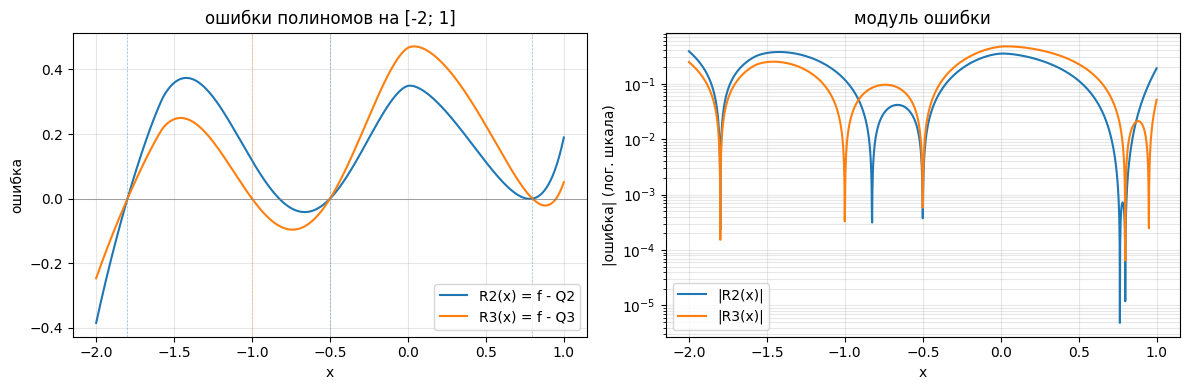

In [7]:
xs = np.linspace(a, b, 2000)
ys = f(xs)
err2 = ys - Q2(xs)
err3 = ys - Q3(xs)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(xs, err2, label='R2(x) = f - Q2')
ax[0].plot(xs, err3, label='R3(x) = f - Q3')
ax[0].axhline(0, color='gray', lw=0.5)
for xn in x_nodes:
    ax[0].axvline(xn, color='C0', lw=0.5, ls='--', alpha=0.5)
ax[0].axvline(x3, color='C1', lw=0.5, ls='--', alpha=0.5)
ax[0].set_xlabel('x')
ax[0].set_ylabel('ошибка')
ax[0].set_title('ошибки полиномов на [-2; 1]')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(xs, np.abs(err2), label='|R2(x)|')
ax[1].plot(xs, np.abs(err3), label='|R3(x)|')
ax[1].set_yscale('log')
ax[1].set_xlabel('x')
ax[1].set_ylabel('|ошибка| (лог. шкала)')
ax[1].set_title('модуль ошибки')
ax[1].legend()
ax[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

In [ ]:
print(f"max|R2| на [-2;1] = {np.nanmax(np.abs(err2)):.4f}")
print(f"max|R3| на [-2;1] = {np.nanmax(np.abs(err3)):.4f}")
print(f"среднее |R2|      = {np.nanmean(np.abs(err2)):.4f}")
print(f"среднее |R3|      = {np.nanmean(np.abs(err3)):.4f}")

max|R2| на [-2;1] = 0.3844
max|R3| на [-2;1] = 0.4711
среднее |R2|      = 0.1686
среднее |R3|      = 0.1764


## 7. сравнение

в узлах $x_0,x_1,x_2$ ошибка $R_2$ обращается в нуль

$R_3$ обнуляется в этих же узлах и дополнительно в $x_3=-1$. остаточный член $R_m(x)=\omega(x)\,f^{(m+1)}(\eta)/(m+1)!$, где $\omega(x)=\prod_i(x-x_i)$.

по числам добавление узла ошибку не уменьшило, а увеличило: $\max|R_2|=0{,}3844$ против $\max|R_3|=0{,}4711$, среднее $0{,}1686$ против $0{,}1764$. три исходных узла чебышёвские и минимизируют $\max|\omega|$, а $x_3=-1$ произволен, поэтому набор из четырёх узлов уже не оптимален. у правого конца множитель $(x-x_3)$ удваивает $|\omega|$, и $R_3$ проигрывает $R_2$.

наибольшая ошибка обоих полиномов сосредоточена у концов промежутка и около $-\pi/2$, где функция меняется быстрее всего.